# Two-Factor Analysis: SNAP Reliance × Store Quality

**Research Question:** To analyze & prioritize LILA tracts based on key food access indicators, providing a decision-support tool to guide Invest Atlanta's future investments towards equitable Fresh Food Access in Atlanta by 2030.

**Two focal factors:**
- **Factor 1 — SNAP Reliance (`TrcSNAP`):** captures economic vulnerability; high SNAP households represent the population most dependent on local food access
- **Factor 2 — Store Quality (`fresh_access_ratio` / `low_access_ratio`):** captures supply-side failure; whether existing food retail actually provides fresh, healthy options

| Plot | Question Answered |
|------|-------------------|
| 1. Investment Priority Quadrant | Which tracts should be prioritized? |
| 2. Store Type Composition       | What type of intervention do they need? |
| 3. Investment Gap Map           | Where are they geographically? |

In [2]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

DATA_PATH = '/Users/jiwonii/Documents/GitHub/fresh-food-access-dashboard/FreshFoodAcessDashboard-InvestATL/data/processed/tract_level_food_access.geojson'

df = gpd.read_file(DATA_PATH).copy()
for col in ['TrcSNAP', 'fresh_access_ratio', 'low_access_ratio', 'P0010001',
            'has_lila', 'need_score', 'high_access_count', 'moderate_access_count',
            'specialty_access_count', 'low_access_count']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

df['investment_gap'] = df['TrcSNAP'] * (1 - df['fresh_access_ratio'])

print(f"Tracts loaded: {len(df)}")
print(f"LILA tracts:   {df['has_lila'].sum()}")
df[['TrcSNAP', 'fresh_access_ratio', 'investment_gap', 'need_score']].describe()

Tracts loaded: 211
LILA tracts:   126


,TrcSNAP,fresh_access_ratio,investment_gap,need_score
count,211.000000,211.000000,211.000000,211.000000
mean,3.585592,0.181497,2.985231,0.381978
std,4.141255,0.335224,3.851366,0.147055
min,0.000000,0.000000,0.000000,0.186681
25%,0.000000,0.000000,0.000000,0.236765
50%,2.470000,0.000000,0.928227,0.376000
75%,5.860000,0.214286,5.150000,0.486227
max,13.000000,1.000000,13.000000,0.736063


## Plot 1 — Investment Priority Quadrant
**SNAP Reliance vs. Fresh Access Ratio**

Tracts in the **top-left quadrant** (high SNAP, low fresh access) are the clearest investment targets — residents are economically vulnerable *and* underserved by quality food retail.

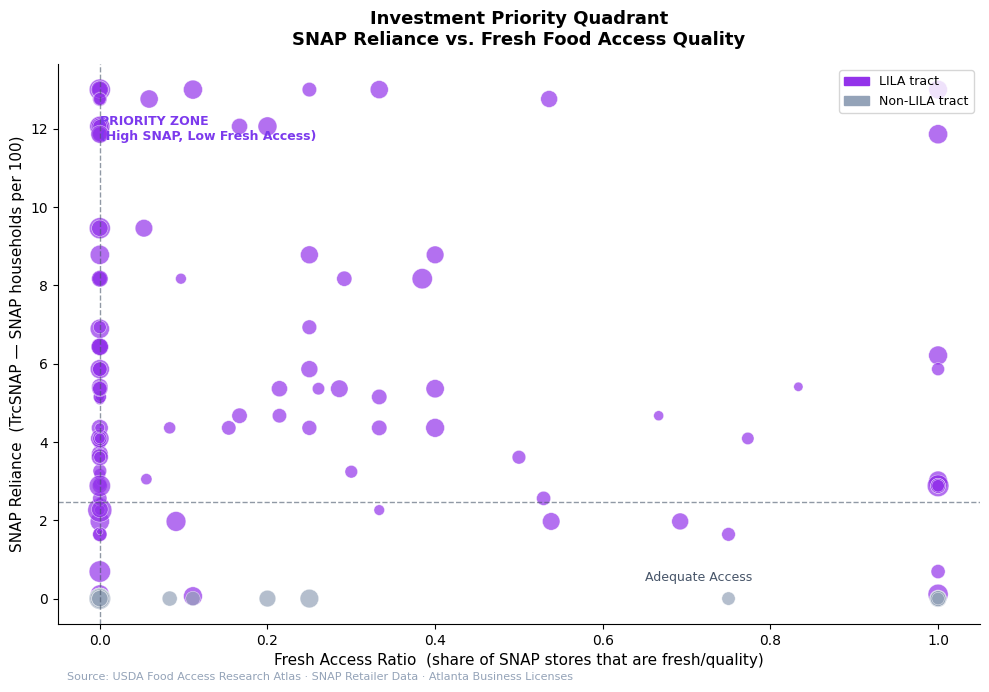

In [8]:
snap_med  = df['TrcSNAP'].median()
fresh_med = df['fresh_access_ratio'].median()

colors = df['has_lila'].map({1: '#9333ea', 0: '#94a3b8'})
sizes  = (df['P0010001'] / df['P0010001'].max() * 300).clip(lower=20)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

ax.scatter(
    df['fresh_access_ratio'], df['TrcSNAP'],
    c=colors, s=sizes, alpha=0.7, edgecolors='white', linewidths=0.4
)

ax.axvline(fresh_med, color='#475569', linewidth=1, linestyle='--', alpha=0.6)
ax.axhline(snap_med,  color='#475569', linewidth=1, linestyle='--', alpha=0.6)

ax.text(fresh_med * 0.05, df['TrcSNAP'].max() * 0.95,
        'PRIORITY ZONE\n(High SNAP, Low Fresh Access)',
        fontsize=9, color='#7c3aed', fontweight='bold', va='top')
ax.text(df['fresh_access_ratio'].max() * 0.65, snap_med * 0.15,
        'Adequate Access',
        fontsize=9, color='#475569', va='bottom')

priority = df[(df['TrcSNAP'] > snap_med) & (df['fresh_access_ratio'] < fresh_med)]
top5 = priority.nlargest(5, 'TrcSNAP')
for _, row in top5.iterrows():
    ax.annotate(
        row['tract_id'].replace('Census Tract ', 'CT '),
        xy=(row['fresh_access_ratio'], row['TrcSNAP']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7.5, color='#1e1b4b'
    )

legend_handles = [
    mpatches.Patch(color='#9333ea', label='LILA tract'),
    mpatches.Patch(color='#94a3b8', label='Non-LILA tract'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)

ax.set_xlabel('Fresh Access Ratio  (share of SNAP stores that are fresh/quality)', fontsize=11)
ax.set_ylabel('SNAP Reliance  (TrcSNAP — SNAP households per 100)', fontsize=11)
ax.set_title(
    'Investment Priority Quadrant\nSNAP Reliance vs. Fresh Food Access Quality',
    fontsize=13, fontweight='bold', pad=14
)
ax.spines[['top', 'right']].set_visible(False)
ax.text(0.01, -0.1,
        'Source: USDA Food Access Research Atlas · SNAP Retailer Data · Atlanta Business Licenses',
        transform=ax.transAxes, fontsize=8, color='#94a3b8')

plt.tight_layout()
plt.show()

## Plot 2 — Store Type Composition for Top 15 LILA Tracts
**What kind of intervention does each priority tract need?**

Bars dominated by **red (convenience stores)** signal tracts where SNAP stores exist but provide little fresh food — these need upgrade/incentive programs. Tracts with **no bars at all** are true food deserts that need new retail development.

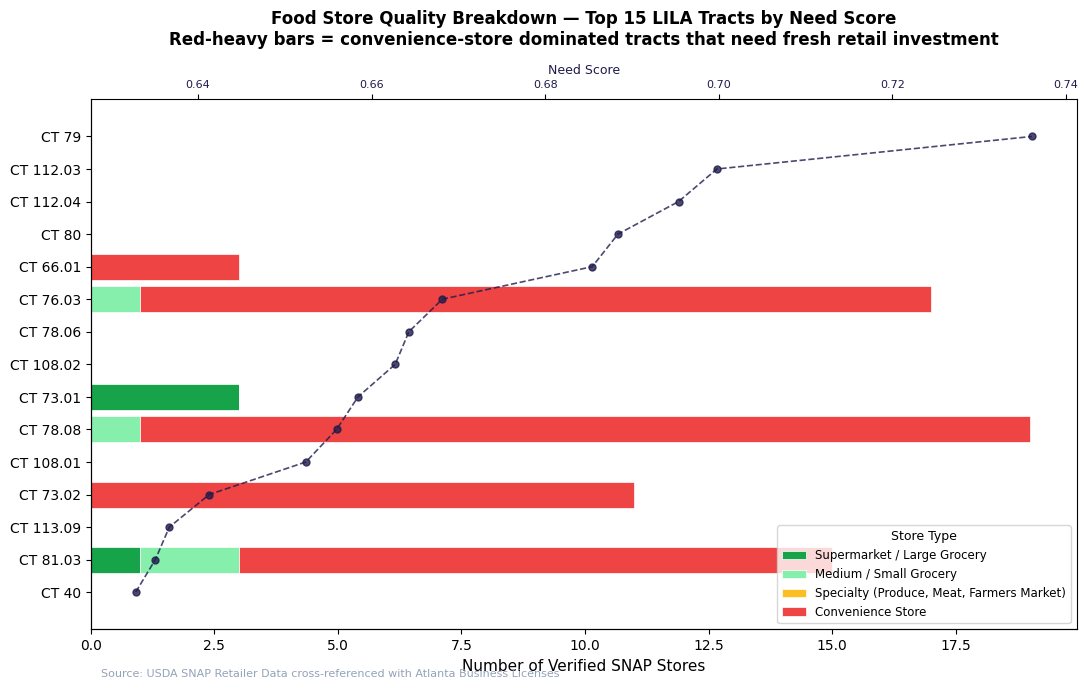

In [9]:
top15 = (
    df[df['has_lila'] == 1]
    .nlargest(15, 'need_score')
    .sort_values('need_score', ascending=True)
)
labels = top15['tract_id'].str.replace('Census Tract ', 'CT ', regex=False)

store_cols   = ['high_access_count', 'moderate_access_count',
                'specialty_access_count', 'low_access_count']
store_labels = ['Supermarket / Large Grocery', 'Medium / Small Grocery',
                'Specialty (Produce, Meat, Farmers Market)', 'Convenience Store']
store_colors = ['#16a34a', '#86efac', '#fbbf24', '#ef4444']

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('white')

lefts = np.zeros(len(top15))
for col, label, color in zip(store_cols, store_labels, store_colors):
    vals = top15[col].values
    ax.barh(labels, vals, left=lefts, color=color, label=label,
            edgecolor='white', linewidth=0.5)
    lefts += vals

ax2 = ax.twiny()
ax2.plot(top15['need_score'].values, range(len(top15)),
         'o--', color='#1e1b4b', markersize=5, linewidth=1.2, alpha=0.8, label='Need Score')
ax2.set_xlabel('Need Score', fontsize=9, color='#1e1b4b')
ax2.tick_params(axis='x', labelcolor='#1e1b4b', labelsize=8)

ax.set_xlabel('Number of Verified SNAP Stores', fontsize=11)
ax.set_title(
    'Food Store Quality Breakdown — Top 15 LILA Tracts by Need Score\n'
    'Red-heavy bars = convenience-store dominated tracts that need fresh retail investment',
    fontsize=12, fontweight='bold', pad=14
)
ax.legend(loc='lower right', fontsize=8.5, title='Store Type', title_fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.text(0.01, -0.09,
        'Source: USDA SNAP Retailer Data cross-referenced with Atlanta Business Licenses',
        transform=ax.transAxes, fontsize=8, color='#94a3b8')

plt.tight_layout()
plt.show()

## Plot 3 — Investment Gap Choropleth Map
**Where are the highest-need, lowest-quality tracts?**

Combined score: `TrcSNAP × (1 − fresh_access_ratio)`. Darker = higher investment gap. **Purple outlines** mark officially designated LILA tracts. Top 10 tracts by investment gap are labeled — these are Invest Atlanta's primary geographic targets.

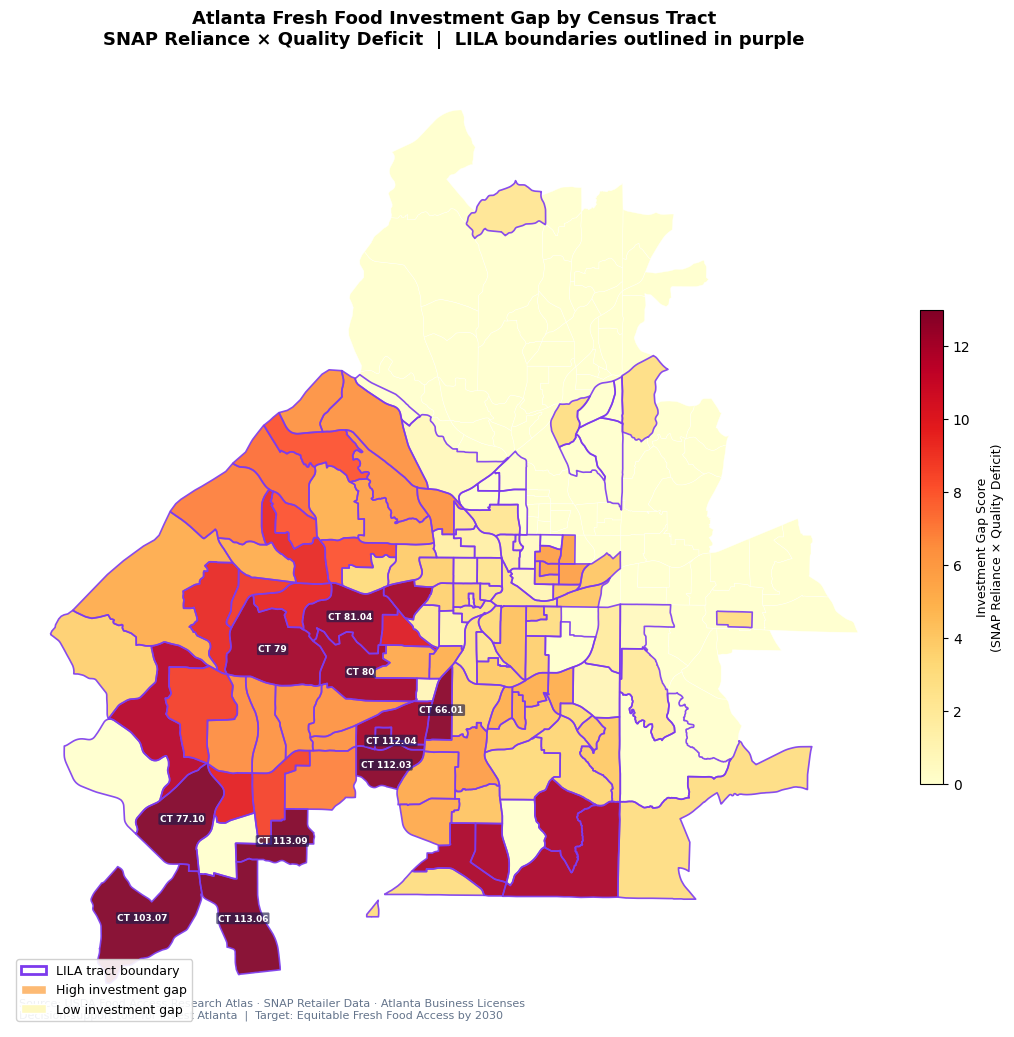

In [10]:
fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f1f5f9')

df.plot(
    ax=ax, column='investment_gap',
    cmap='YlOrRd', edgecolor='white', linewidth=0.3, alpha=0.92
)

df[df['has_lila'] == 1].boundary.plot(
    ax=ax, color='#7c3aed', linewidth=1.2, alpha=0.9
)

top10 = df.nlargest(10, 'investment_gap')
for _, row in top10.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    label = row['tract_id'].replace('Census Tract ', 'CT ')
    ax.annotate(
        label, xy=(cx, cy),
        fontsize=6.5, ha='center', va='center',
        color='white', fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', fc='#1e1b4b', alpha=0.65, lw=0)
    )

norm = Normalize(vmin=df['investment_gap'].min(), vmax=df['investment_gap'].max())
sm = ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.45, pad=0.02)
cbar.set_label('Investment Gap Score\n(SNAP Reliance × Quality Deficit)', fontsize=9)

legend_handles = [
    mpatches.Patch(facecolor='none', edgecolor='#7c3aed',
                   linewidth=2, label='LILA tract boundary'),
    mpatches.Patch(facecolor='#fdba74', edgecolor='white', label='High investment gap'),
    mpatches.Patch(facecolor='#fef9c3', edgecolor='white', label='Low investment gap'),
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=9,
          frameon=True, framealpha=0.9)

ax.set_title(
    'Atlanta Fresh Food Investment Gap by Census Tract\n'
    'SNAP Reliance × Quality Deficit  |  LILA boundaries outlined in purple',
    fontsize=13, fontweight='bold', pad=16
)
ax.text(0.01, 0.01,
        'Source: USDA Food Access Research Atlas · SNAP Retailer Data · Atlanta Business Licenses\n'
        'Decision-support tool for Invest Atlanta  |  Target: Equitable Fresh Food Access by 2030',
        transform=ax.transAxes, fontsize=8, color='#64748b')
ax.set_axis_off()

plt.tight_layout()
plt.show()